# Assignment 1: Pre-processing & Language Modeling on SMS Spam/Ham Dataset

### Objectives

By the end of this assignment, you will be able to:

- Build a configurable text pre-processing pipeline by implementing a series of atomic functions.

- Apply this pipeline to a Spam vs. Ham SMS dataset.

- Use class-conditional statistics to identify domain-specific stopwords.

### Project Setup & Warm-up

#### 1. Data Loading & Initial Setup

In [21]:
from datasets import load_dataset

# Load the dataset from Hugging Face

dataset = load_dataset("sms_spam")['train']

In [22]:
dataset[0]

{'sms': 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n',
 'label': 0}

In [23]:
# Create spam and ham text lists

spam_texts = [item['sms'] for item in dataset if item['label'] == 1]
ham_texts  = [item['sms'] for item in dataset if item['label'] == 0]

print(f"Number of SPAM messages: {len(spam_texts)}")
print(f"Number of HAM messages:  {len(ham_texts)}")

Number of SPAM messages: 747
Number of HAM messages:  4827


In [24]:
print('HAM Examples:')
print('-------------\n')

for i in range(5):
    print(ham_texts[i].strip())
    print()

HAM Examples:
-------------

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Ok lar... Joking wif u oni...

U dun say so early hor... U c already then say...

Nah I don't think he goes to usf, he lives around here though

Even my brother is not like to speak with me. They treat me like aids patent.



In [25]:
print('SPAM Examples:')
print('--------------\n')

for i in range(5):
    print(spam_texts[i].strip())
    print()

SPAM Examples:
--------------

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030

SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info



#### 2. Implement the Pipeline Functions

In [27]:
import nltk, random
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from typing import List, Callable

random.seed(11)

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

_lem  = WordNetLemmatizer()
_stem = PorterStemmer()

def word_tokenize_sentence(sent: str) -> List[str]:
    # TODO: Use nltk.word_tokenize
    return nltk.word_tokenize(sent)

def to_lower(tokens: List[str]) -> List[str]:
    # TODO: Convert all tokens to lowercase
    return [token.lower() for token in tokens]

def remove_punct_digits(tokens: List[str]) -> List[str]:
    # TODO: Keep only alphabetic tokens
    return [token for token in tokens if token.isalpha()]

def remove_stopwords(tokens: List[str]) -> List[str]:
    # TODO: Remove NLTK English stopwords and any extra stops
    stop_words = set(stopwords.words('english'))
    return [token for token in tokens if token not in stop_words]

def lemmatize(tokens: List[str]) -> List[str]:
    # TODO: Apply WordNet lemmatization
    return [_lem.lemmatize(token) for token in tokens]

def stem(tokens: List[str]) -> List[str]:
    # TODO: Apply Porter stemming
    return [_stem.stem(token) for token in tokens]

#### 3. Implement the Pipeline Runner

In [28]:
def apply_steps_to_sentence(sent: str, steps: List[Callable]) -> List[str]:
    # TODO: Apply the provided list of functions in order
    processed_output = sent
    for step_func in steps:
        processed_output = step_func(processed_output)
    return processed_output

def run_pipeline(text: str, steps: List[Callable]) -> List[List[str]]:
    """
    Processes a single text string by first tokenizing it into sentences,
    then applying the specified pipeline steps to each sentence.
    """
    sentences              = nltk.sent_tokenize(text)
    preprocessed_sentences = []

    for sent in sentences:
        tokenized_sentence = apply_steps_to_sentence(sent, steps)
        preprocessed_sentences.append(tokenized_sentence)

    return preprocessed_sentences

#### Deterministic Check on `Sherlock Holmes`

Save the results from the first 5 sentences in `sherlock_preprocessed.txt`.

In [29]:
with open('sherlock_holmes.txt', 'r') as f:

  sherlock_snippet = f.read()

print(sherlock_snippet)

IN the year 1878 I took my degree of Doctor of Medicine of the University of London, and proceeded to Netley to go through the course prescribed for surgeons in the army. Having completed my studies there, I was duly attached to the Fifth Northumberland Fusiliers as Assistant Surgeon. The regiment was stationed in India at the time, and before I could join it, the second Afghan war had broken out. On landing at Bombay, I learned that my corps had advanced through the passes, and was already deep in the enemy\'s country. I followed, however, with many other officers who were in the same situation as myself, and succeeded in reaching Candahar in safety, where I found my regiment, and at once entered upon my new duties.\n\nThe campaign brought honours and promotion to many, but for me it had nothing but misfortune and disaster. I was removed from my brigade and attached to the Berkshires, with whom I served at the fatal battle of Maiwand. There I was struck on the shoulder by a Jezail bul

In [30]:
# Define the pipeline steps to include stemming but not lemmatization

pipeline_steps_stemming = [
    word_tokenize_sentence,
    to_lower,
    remove_punct_digits,
    remove_stopwords,
    stem
]

# Run the pipeline on the Sherlock snippet
processed_sherlock_snippet = run_pipeline(sherlock_snippet, pipeline_steps_stemming)

# Print the results
print("\nProcessed Snippet (with stemming):\n")
for sentence in processed_sherlock_snippet[:5]:
    print(sentence)


Processed Snippet (with stemming):

['year', 'took', 'degre', 'doctor', 'medicin', 'univers', 'london', 'proceed', 'netley', 'go', 'cours', 'prescrib', 'surgeon', 'armi']
['complet', 'studi', 'duli', 'attach', 'fifth', 'northumberland', 'fusili', 'assist', 'surgeon']
['regiment', 'station', 'india', 'time', 'could', 'join', 'second', 'afghan', 'war', 'broken']
['land', 'bombay', 'learn', 'corp', 'advanc', 'pass', 'alreadi', 'deep', 'countri']
['follow', 'howev', 'mani', 'offic', 'situat', 'succeed', 'reach', 'candahar', 'safeti', 'found', 'regiment', 'enter', 'upon', 'new', 'campaign', 'brought', 'honour', 'promot', 'mani', 'noth', 'misfortun', 'disast']


Processed Snippet (5 First Sentences) with Stemming:

```
['year', 'took', 'degre', 'doctor', 'medicin', 'univers', 'london', 'proceed', 'netley', 'go', 'cours', 'prescrib', 'surgeon', 'armi']
['complet', 'studi', 'duli', 'attach', 'fifth', 'northumberland', 'fusili', 'assist', 'surgeon']
['regiment', 'station', 'india', 'time', 'could', 'join', 'second', 'afghan', 'war', 'broken']
['land', 'bombay', 'learn', 'corp', 'advanc', 'pass', 'alreadi', 'deep', 'enemi', 'countri']
['follow', 'howev', 'mani', 'offic', 'situat', 'succeed', 'reach', 'candahar', 'safeti', 'found', 'regiment', 'enter', 'upon', 'new', 'duti']
```

In [31]:
with open('sherlock_preprocessed.txt', 'w') as file:

    for sentence in processed_sherlock_snippet:

        file.write(', '.join(sentence) + '\n')

### Part A: Classwise Pre-processing & Analysis

#### 1. Identify Domain-Specific Stopwords

In [32]:
from collections import defaultdict

pipeline_steps_lemmatization = [
    word_tokenize_sentence,
    to_lower,
    remove_punct_digits,
    remove_stopwords,
    stem
]

def process_texts(texts: List[str], steps: List[Callable]) -> List[List[str]]:
    processed_docs = []
    for text in texts:
        # Each SMS is a single document; flatten the sentence-based output
        doc_tokens = [token for sentence in run_pipeline(text, steps) for token in sentence]
        processed_docs.append(doc_tokens)
    return processed_docs

processed_spam_docs = process_texts(spam_texts, pipeline_steps_stemming)
processed_ham_docs = process_texts(ham_texts, pipeline_steps_stemming)

tokenized_docs_all = {
    "spam": processed_spam_docs,
    "ham": processed_ham_docs
}


def doc_frequency(tokenized_docs):
    """
    This function should calculate how many documents (per class) contain each word at least once.

    Input:
    tokenized_docs → a dictionary where:
      - keys are class labels (e.g., "spam", "ham")
      - values are lists of tokenized documents for that class

    Example input:
    {
      "spam": [["buy", "cheap", "viagra"], ["cheap", "offer"]],
      "ham": [["see", "you", "tomorrow"], ["let's", "have", "lunch"]]
    }

    Expected Output:
    Two dictionaries (`return df, totals`):
    1. df (document frequencies):
    {
      "cheap": {"spam": 2, "ham": 1},
      "see": {"spam": 1, "ham": 1},
      ...
    }

    2. totals (number of documents per class):
    {"spam": 2, "ham": 2}

    """
    df = defaultdict(lambda: defaultdict(int))
    totals = defaultdict(int)

    for label, docs in tokenized_docs.items():
        totals[label] = len(docs)
        for doc in docs:
            for token in set(doc): # Use set for document frequency (count once per doc)
                df[token][label] += 1
    return df, totals

def relative_df(df, totals):
    """
    Computes the relative document frequency of words per class.

    The idea: normalize the document frequency of each word by the total number of documents in that class.

    TODO: compute rdf[word][label] = df[word][label] / totals[label]
    """
    rdf = defaultdict(lambda: defaultdict(float))
    for token, labels in df.items():
        for label, count in labels.items():
            rdf[token][label] = count / totals[label]
    return rdf

def domain_stopwords_from_rdf(rdf, threshold=0.01):
    """
    Identify domain-specific stopwords based on relative document frequency (RDF).

    A word is considered a domain-specific stopword if:
    - it appears in all classes, AND
    - the maximum RDF difference between classes is smaller than the threshold.

    Input:
    rdf → dict of word → {class_label: relative_df_value}
    threshold → maximum allowed difference (default = 0.01)

    Expected Output:
    A dictionary of words that behave like stopwords across all classes, and their
    rdf scores for each class.
    Example:
    {
      "get": {"spam_rdf": 0.04284, "ham_rdf": 0.03646},
      "week": {"spam_rdf": 0.05489, "ham_rdf": 0.00912},
    }
    """
    domain_stopwords = {}
    labels = list(rdf[next(iter(rdf))].keys())
    if len(labels) < 2:
        return domain_stopwords

    for token, rdf_scores in rdf.items():
        # Check if the word appears in all classes
        if all(label in rdf_scores for label in ['spam', 'ham']):
            spam_rdf = rdf_scores['spam']
            ham_rdf = rdf_scores['ham']
            
            # Check if the RDF difference is below the threshold
            if abs(spam_rdf - ham_rdf) < threshold:
                domain_stopwords[token] = {
                    "spam_rdf": spam_rdf,
                    "ham_rdf": ham_rdf
                }
    return domain_stopwords


In [33]:
def remove_domain_stopwords(tokens: List[str], domain_stops: List[str]) -> List[str]:
    # TODO: Implement this function to remove tokens in the domain_stops list.
    return [token for token in tokens if token not in domain_stops]

#### 2. Analyze and Report Results

#### `a)` Print the top 20 domain-specific stopwords, along with their SPAM and HAM RDF Scores.

Create a `domain_stopwords.txt` file in the format of `token`,`spam_rdf`,`ham_rdf`:

```
get,0.04284,0.03646        
week,0.05489,0.00912        
phone,0.05087,0.01139
...
```

In [34]:
df, totals = doc_frequency(tokenized_docs_all)
rdf = relative_df(df, totals)

# Identify domain stopwords
domain_stopwords_dict = domain_stopwords_from_rdf(rdf, threshold=0.01)

# Sort domain stopwords by average RDF for printing
sorted_domain_stopwords = sorted(
    domain_stopwords_dict.items(),
    key=lambda item: (item[1]['spam_rdf'] + item[1]['ham_rdf']) / 2,
    reverse=True
)

print("Top-20 Domain-Specific Stopwords (sorted by average RDF):\n")
print(f"{'Token':<10} | {'SPAM RDF':<15} | {'HAM RDF':<15}")
print("-" * 45)
for token, scores in sorted_domain_stopwords[:20]:
    print(f"{token:<10} | {scores['spam_rdf']:<15.5f} | {scores['ham_rdf']:<15.5f}")

# Save to file
with open('domain_stopwords.txt', 'w') as f:
    for token, scores in sorted_domain_stopwords:
        f.write(f"{token},{scores['spam_rdf']},{scores['ham_rdf']}\n")

domain_stops_list = list(domain_stopwords_dict.keys())

Top-20 Domain-Specific Stopwords (sorted by average RDF):

Token      | SPAM RDF        | HAM RDF        
---------------------------------------------
u          | 0.15395         | 0.14564        
want       | 0.04150         | 0.04226        
day        | 0.03748         | 0.04226        
see        | 0.02544         | 0.03170        
back       | 0.02945         | 0.02590        
take       | 0.02276         | 0.03087        
tell       | 0.02410         | 0.02714        
wait       | 0.02544         | 0.02010        
hi         | 0.02276         | 0.02113        
make       | 0.01740         | 0.02631        
dear       | 0.02142         | 0.01885        
friend     | 0.02142         | 0.01761        
thank      | 0.02142         | 0.01719        
ye         | 0.02008         | 0.01637        
great      | 0.01473         | 0.01989        
miss       | 0.01339         | 0.02113        
give       | 0.01205         | 0.02134        
wan        | 0.01606         | 0.01657        
pl

#### `b)` Comparison of **token frequencies** and **vocabulary sizes** before and after incrementally applying each pre-processing step in this order:

- `None`
- `to_lower`
- `remove_punct_digits`
- `remove_stopwords`
- `stem`
- `remove_domain_stopwords`

For example:

- First you calculate the above with no pre-processing.
- Then, with `to_lower`.
- Then, with `to_lower` + `remove_punct_digits`
- etc.

Store the results in a `vocabulary_sizes.txt` file in the format of Step,Token Size,Vocabulary Size:

```
Raw,105094,11516          
To Lower,105094,9407           
Remove Punctuation & Digits,81939,7354
...
```

In [35]:
all_texts = spam_texts + ham_texts
results = []

# Step 1: Raw
raw_tokens_nested = [nltk.word_tokenize(text) for text in all_texts]
raw_tokens_flat = [token for doc in raw_tokens_nested for token in doc]
results.append(('Raw', len(raw_tokens_flat), len(set(raw_tokens_flat))))

# Step 2: To Lower
lower_tokens = to_lower(raw_tokens_flat)
results.append(('To Lower', len(lower_tokens), len(set(lower_tokens))))

# Step 3: Remove Punctuation & Digits
alpha_tokens = remove_punct_digits(lower_tokens)
results.append(('Remove Punctuation & Digits', len(alpha_tokens), len(set(alpha_tokens))))

# Step 4: Remove Stopwords
no_stopwords_tokens = remove_stopwords(alpha_tokens)
results.append(('Remove Stopwords', len(no_stopwords_tokens), len(set(no_stopwords_tokens))))

# Step 5: Lemmatization
lemmatized_tokens = lemmatize(no_stopwords_tokens)
results.append(('Lemmatization', len(lemmatized_tokens), len(set(lemmatized_tokens))))

# Step 6: Remove Domain Stopwords
final_tokens = remove_domain_stopwords(lemmatized_tokens, domain_stops_list)
results.append(('Remove Domain Stopwords', len(final_tokens), len(set(final_tokens))))


# Print and save results
print("\nVocabulary Size Analysis:\n")
with open('vocabulary_sizes.txt', 'w') as f:
    f.write("Step,Token Size,Vocabulary Size\n")
    print(f"{'Step':<30} | {'Token Size':<15} | {'Vocabulary Size':<15}")
    print("-" * 65)
    for name, total, vocab in results:
        f.write(f"{name},{total},{vocab}\n")
        print(f"{name:<30} | {total:<15} | {vocab:<15}")


#### Fully pre-processed data for frequency analysis
final_pipeline_steps = [
    word_tokenize_sentence,
    to_lower,
    remove_punct_digits,
    remove_stopwords,
    stem
]

final_spam_docs = process_texts(spam_texts, final_pipeline_steps)
final_ham_docs = process_texts(ham_texts, final_pipeline_steps)

# Flatten lists for frequency distribution
flat_spam_tokens = [token for doc in final_spam_docs for token in doc]
flat_ham_tokens = [token for doc in final_ham_docs for token in doc]

from collections import Counter

spam_freq = Counter(flat_spam_tokens)
ham_freq = Counter(flat_ham_tokens)

spam_vocab = set(spam_freq.keys())
ham_vocab = set(ham_freq.keys())


Vocabulary Size Analysis:

Step                           | Token Size      | Vocabulary Size
-----------------------------------------------------------------
Raw                            | 105094          | 11516          
To Lower                       | 105094          | 9407           
Remove Punctuation & Digits    | 81939           | 7354           
Remove Stopwords               | 47270           | 7217           
Lemmatization                  | 47270           | 6713           
Remove Domain Stopwords        | 36619           | 6229           


Visualize the impact of each pre-processing step.

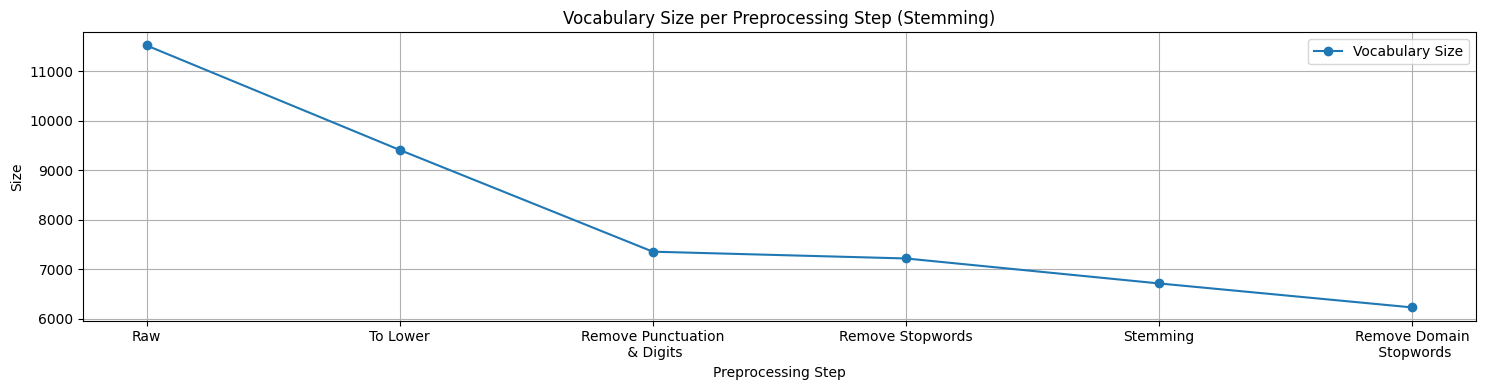

In [36]:
import matplotlib.pyplot as plt

steps = [
    'Raw',
    'To Lower',
    'Remove Punctuation\n & Digits',
    'Remove Stopwords',
    'Stemming',
    'Remove Domain\n Stopwords'
]

# `vocab_sizes` must be a list with 6 values, each corresponding to the vocabulary
# size of the respective pre-processing step (incrementally).

vocab_sizes = [11516, 9407, 7354, 7217, 6713, 6229]

plt.figure(figsize=(15, 4))
plt.plot(steps, vocab_sizes, marker='o', label='Vocabulary Size')
plt.xlabel('Preprocessing Step')
plt.ylabel('Size')
plt.title('Vocabulary Size per Preprocessing Step (Stemming)')
plt.xticks(rotation=0, ha='center')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### `c)` Identify and print the top-10 frequent tokens that appear only in `SPAM`.

Print each token in a separate line in `only_spam.txt`

In [ ]:
spam_only_vocab = spam_vocab - ham_vocab
top_10_spam_only = sorted([(token, spam_freq[token]) for token in spam_only_vocab], key=lambda x: x[1], reverse=True)[:10]

print("\nTop-10 frequent tokens ONLY in SPAM:")
with open('only_spam.txt', 'w') as f:
    for token, freq in top_10_spam_only:
        print(f"{token}: {freq}")
        f.write(f"{token},{freq}\n")


Top-10 frequent tokens ONLY in SPAM:
claim: 115
prize: 94
tone: 74
guarante: 51
cs: 41
rington: 34
entri: 26
mob: 25
poli: 25
weekli: 24


#### `d)` Identify and print the top-10 frequent tokens that appear only in `HAM`.

Print each token in a separate line in `only_ham.txt`

In [38]:
ham_only_vocab = ham_vocab - spam_vocab
top_10_ham_only = sorted([(token, ham_freq[token]) for token in ham_only_vocab], key=lambda x: x[1], reverse=True)[:10]

print("\nTop-10 frequent tokens ONLY in HAM:")
with open('only_ham.txt', 'w') as f:
    for token, freq in top_10_ham_only:
        print(f"{token}: {freq}")
        f.write(f"{token},{freq}\n")


Top-10 frequent tokens ONLY in HAM:
gt: 318
lt: 316
ü: 173
lor: 162
da: 150
later: 135
said: 89
amp: 88
morn: 81
sleep: 79


#### `e)` Identify and print the top-10 frequent tokens that appear in `SPAM` and `HAM`.

Print each token in a separate line in `spam_ham.txt`

In [39]:
common_vocab = spam_vocab.intersection(ham_vocab)
top_10_common = sorted(
    [(token, spam_freq[token] + ham_freq[token]) for token in common_vocab],
    key=lambda x: x[1],
    reverse=True
)[:10]

print("\nTop-10 frequent tokens in BOTH SPAM and HAM:")
with open('spam_ham.txt', 'w') as f:
    for token, freq in top_10_common:
        print(f"{token}: {freq}")
        f.write(f"{token},{freq}\n")


Top-10 frequent tokens in BOTH SPAM and HAM:
u: 1151
call: 658
go: 455
get: 447
ur: 391
come: 303
free: 278
know: 275
ok: 267
like: 259
